In [9]:
from ultralytics import YOLO
import os
import cv2
import torch
import math
from modules_demo import *
from modules_prediction import *
import json

In [10]:
model = YOLO(f"/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/runs/detect/train/weights/best.pt")

image_dirs = [
        "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/split/images/train",
        "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/split/images/val"
    ]

# tile labels folder
label_dirs = [
    "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles/train/labels",
    "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles/val/labels"
]

#output folder for predictions
output_dir = f"/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/predictions"
os.makedirs(output_dir, exist_ok=True)

 # output dict structured by FN/FP/TP -> species -> image
json_results = {"FN": {}, "FP": {}, "TP": {}}

image_dir = image_dirs[0]
label_dir = label_dirs[0]
filename = os.listdir(image_dir)[1]
print(filename)

BRAIIM_0003.jpg


In [11]:
image_path = os.path.join(image_dir, filename)
image = cv2.imread(image_path)
boxes, confs, class_ids = sliding_window_prediction(image, model)
print(boxes[0], confs[0], class_ids[0])
print(len(boxes))
#show(draw_boxes(image, boxes))
boxes, confs, class_ids = nms(boxes, confs, class_ids, iou_threshold=0.4, device=model.device)
print(len(boxes))
#show(draw_boxes(image, boxes))
boxes, confs, class_ids = filter_mostly_contained_boxes(boxes, confs, class_ids, threshold=0.5)
print(len(boxes))
#show(draw_boxes(image, boxes))

tensor([233.7708,  59.0837, 372.9187, 180.9738], device='cuda:0') tensor(0.8137, device='cuda:0') tensor(0., device='cuda:0')
45
22
20


In [12]:
pred_tiles_data = get_labels_per_tile_tensor(image, boxes, class_ids, confs)
print(pred_tiles_data)
label_tiles_data = load_label_tiles(label_dir, filename)      
print(label_tiles_data)      

[tensor([[0.0000, 0.4740, 0.1875, 0.2174, 0.1905, 0.8137]], device='cuda:0'), tensor([[0.0000, 0.5133, 0.4594, 0.2444, 0.1840, 0.8396]], device='cuda:0'), tensor([], device='cuda:0', size=(0, 6)), tensor([], device='cuda:0', size=(0, 6)), tensor([], device='cuda:0', size=(0, 6)), tensor([], device='cuda:0', size=(0, 6)), tensor([], device='cuda:0', size=(0, 6)), tensor([], device='cuda:0', size=(0, 6)), tensor([], device='cuda:0', size=(0, 6)), tensor([[0.0000, 0.3681, 0.3836, 0.1632, 0.1582, 0.4567]], device='cuda:0'), tensor([[0.0000, 0.3339, 0.3859, 0.1617, 0.2010, 0.8319],
        [3.0000, 0.5307, 0.4712, 0.0575, 0.0504, 0.3132]], device='cuda:0'), tensor([], device='cuda:0', size=(0, 6)), tensor([], device='cuda:0', size=(0, 6)), tensor([], device='cuda:0', size=(0, 6)), tensor([], device='cuda:0', size=(0, 6)), tensor([[0.0000, 0.6675, 0.4642, 0.2082, 0.1750, 0.9178]], device='cuda:0'), tensor([[0.0000, 0.8418, 0.2787, 0.2617, 0.1966, 0.7693]], device='cuda:0'), tensor([[0.0000, 

In [13]:
check_tiles = []
for i, (pred_tile_data, label_tile_data) in enumerate(zip(pred_tiles_data, label_tiles_data)):

    # Prediction boxes (YOLO → XYXY)
    pred_bboxes_yolo = pred_tile_data[:, 1:5]   # nx, ny, nw, nh
    pred_bboxes_xyxy = yolo_to_xyxy_tensor(pred_bboxes_yolo)

    # Ground-truth boxes (YOLO → XYXY)
    label_bboxes_yolo = label_tile_data[:, 1:5]  # assuming same format
    label_bboxes_xyxy = yolo_to_xyxy_tensor(label_bboxes_yolo)

    # Load corresponding tile
    file = os.path.splitext(filename)[0] + f"_tile_{i}.jpg"
    img = cv2.imread(os.path.join(
        "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles/train/images",
        file
    ))

    # Draw predictions (blue) and labels (green)
    img_drawn = draw_boxes(img, pred_bboxes_xyxy, color=(255,0,0), thickness=2)
    img_drawn = draw_boxes(img_drawn, label_bboxes_xyxy, color=(0,255,0), thickness=2)

    check_tiles.append(img_drawn)

In [14]:
results = []

for tile_id, (pred, label) in enumerate(zip(pred_tiles_data, label_tiles_data)):
    if pred.numel() == 0:
        pred_boxes = torch.empty((0, 4), device='cuda')
        pred_classes = torch.empty((0,), dtype=torch.long, device='cuda')
        pred_scores = torch.empty((0,), device='cuda')
    else:
        pred_boxes = pred[:, 1:5]
        pred_classes = pred[:, 0].long()
        pred_scores = pred[:, 5]

    if label.numel() == 0:
        gt_boxes = torch.empty((0, 4), device='cuda')
        gt_classes = torch.empty((0,), dtype=torch.long, device='cuda')
    else:
        gt_boxes = label[:, 1:5]
        gt_classes = label[:, 0].long()

    tp, fp, fn = compare_labels_vectorized(
        pred_boxes, pred_classes, pred_scores, gt_boxes, gt_classes
    )

    results.append((tp, fp, fn))


In [15]:
for i, (tp, fp, fn) in enumerate(results):
    if tp[0] or fp[0] or fn[0]:  # any list is non-empty
        print(f"Tile {i}:")
        print("  TP:", tp)
        print("  FP:", fp)
        print("  FN:", fn)

Tile 0:
  TP: ([[233.77078247070312, 59.08372497558594, 372.9187316894531, 180.9738006591797]], [0], [0.8137310743331909])
  FP: ([], [], [])
  FN: ([], [])
Tile 1:
  TP: ([[250.30047607421875, 235.13690185546875, 406.74505615234375, 352.92706298828125]], [0], [0.8396214842796326])
  FP: ([], [], [])
  FN: ([], [])
Tile 9:
  TP: ([[183.38185119628906, 194.9107666015625, 287.818359375, 296.1534423828125]], [0], [0.4566827416419983])
  FP: ([], [], [])
  FN: ([], [])
Tile 10:
  TP: ([[161.93603515625, 182.69424438476562, 265.40087890625, 311.30810546875]], [0], [0.831911027431488])
  FP: ([[321.256591796875, 285.4573974609375, 358.036376953125, 317.6943359375]], [3], [0.31324854493141174])
  FN: ([], [])
Tile 15:
  TP: ([[360.59149169921875, 241.108154296875, 493.84124755859375, 353.100830078125]], [0], [0.9177568554878235])
  FP: ([], [], [])
  FN: ([], [])
Tile 16:
  TP: ([], [], [])
  FP: ([[455.03167724609375, 115.45388793945312, 622.5337524414062, 241.28976440429688]], [0], [0.76931

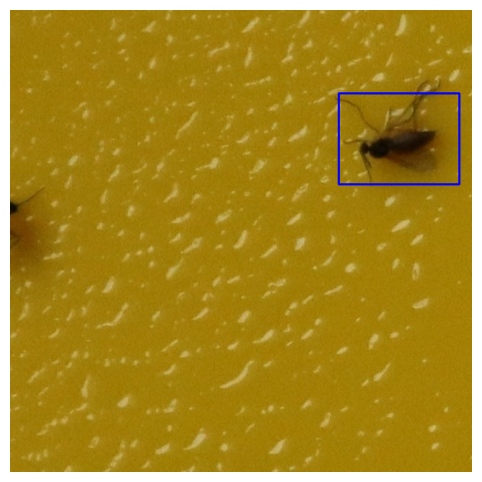

In [16]:
show(check_tiles[16])

In [17]:
species = filename.split("_")[0]  # extract species from filename

# This is the per-tile loop:
for tile_id, (pred, label) in enumerate(zip(pred_tiles_data, label_tiles_data)):
    # pred = predictions for tile i
    # label = labels for tile i

    if pred.numel() == 0:
        pred_boxes = torch.empty((0, 4), device='cuda')
        pred_classes = torch.empty((0,), dtype=torch.long, device='cuda')
        pred_scores = torch.empty((0,), device='cuda')
    else:
        pred_boxes = pred[:, 1:5]
        pred_classes = pred[:, 0].long()
        pred_scores = pred[:, 5]

    if label.numel() == 0:
        gt_boxes = torch.empty((0, 4), device='cuda')
        gt_classes = torch.empty((0,), dtype=torch.long, device='cuda')
    else:
        gt_boxes = label[:, 1:5]
        gt_classes = label[:, 0].long()

    # Call your function **per tile**
    tp, fp, fn = compare_labels_vectorized(
        pred_boxes, pred_classes, pred_scores, gt_boxes, gt_classes
    )

    species = filename.split("_")[0]  # extract species from filename

    # --- Add entries to JSON with tile_id ---
    for category, items in zip(["TP", "FP", "FN"], [tp, fp, fn]):
        boxes, classes, scores = items if category != "FN" else (*items, [None]*len(items[0]))
        if len(classes) > 0:
            json_results.setdefault(category, {}).setdefault(species, {}).setdefault(filename, [])
            for cls, box, score in zip(classes, boxes, scores):
                entry = {"tile_id": tile_id}
                if category != "FN":
                    entry["prediction"] = [cls, *box, score]
                else:
                    entry["prediction"] = [cls, *box]
                json_results[category][species][filename].append(entry)

In [18]:
json_results

{'FN': {},
 'FP': {'BRAIIM': {'BRAIIM_0003.jpg': [{'tile_id': 10,
     'prediction': [3,
      321.256591796875,
      285.4573974609375,
      358.036376953125,
      317.6943359375,
      0.31324854493141174]},
    {'tile_id': 16,
     'prediction': [0,
      455.03167724609375,
      115.45388793945312,
      622.5337524414062,
      241.28976440429688,
      0.7693189978599548]},
    {'tile_id': 17,
     'prediction': [0,
      15.031684875488281,
      115.45388793945312,
      182.53375244140625,
      241.28976440429688,
      0.7693189978599548]}]}},
 'TP': {'BRAIIM': {'BRAIIM_0003.jpg': [{'tile_id': 0,
     'prediction': [0,
      233.77078247070312,
      59.08372497558594,
      372.9187316894531,
      180.9738006591797,
      0.8137310743331909]},
    {'tile_id': 1,
     'prediction': [0,
      250.30047607421875,
      235.13690185546875,
      406.74505615234375,
      352.92706298828125,
      0.8396214842796326]},
    {'tile_id': 9,
     'prediction': [0,
      183.381

In [11]:
thresholds = [
    {"BRAIIM": 0.5, "LIRIBO": 0.5, "FRANOC": 0, "TRIAVA": 0.5}   
]

[0.8418479919433594, 0.2787059783935547, 0.2617219924926758, 0.19661855697631836]
BRAIIM_0003.jpg 16


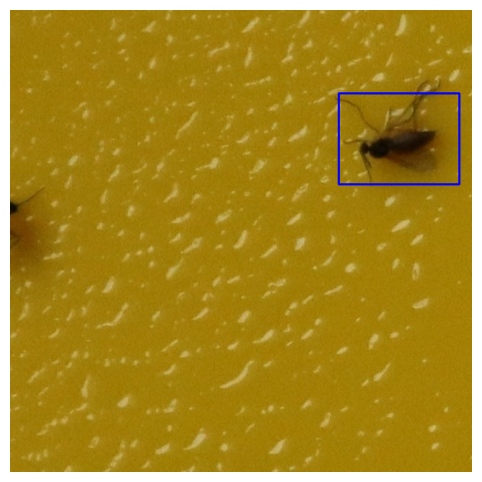

[0.15434799790382386, 0.2787059783935547, 0.26172198057174684, 0.19661855697631836]
BRAIIM_0003.jpg 17


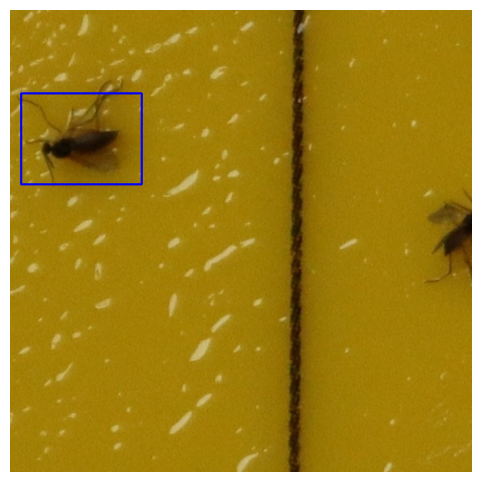

In [12]:

# Only FP predictions from the JSON

# Mapping of base image folders to tile label folders
folder_mapping = {
    "train": "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles/train/labels_training_run",
    "val": "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles/val/labels_training_run"
}

data = json_results["FP"]

total_preds_appended = 0

for species_name, images in data.items():
    for base_name, entries in images.items():

        # Determine if the image belongs to train or val
        if base_name in os.listdir("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/split/images/train"):
            tile_folder = folder_mapping["train"]
        elif base_name in os.listdir("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/split/images/val"):
            tile_folder = folder_mapping["val"]
        else:
            print(f"Warning: {base_name} not found in train or val images. Skipping.")
            continue

        for entry in entries:
            tile_id = entry['tile_id']
            pred = entry['prediction']  # [class_id, x1, y1, x2, y2, conf]

            # Unpack prediction
            class_id, x1, y1, x2, y2, conf = pred

            # Apply threshold
            threshold = thresholds[0][species_name]
            if conf < threshold:
                continue

            # Correct class according to filename if needed
            gt_class_id = list(thresholds[0].keys()).index(species_name)
            class_id = gt_class_id  # enforce correct class

            # Path to the existing tile label file
            base_filename = os.path.splitext(base_name)[0]  # e.g., "LIRIBO_0629"
            tile_file = os.path.join(tile_folder, f"{base_filename}_tile_{tile_id}.txt")

            # Append the FP prediction directly
            yolo_box = xyxy_to_yolo(x1, y1, x2, y2, tile_size=640)
            print(yolo_box)

            total_preds_appended += 1
            print(base_name, tile_id)
            show(check_tiles[tile_id])

In [32]:
import os
import shutil

# List of prefixes to match
prefixes = [
    "LIRIBO_0629",
    "LIRIBO_0630",

]

# Source folders (fresh)
src_folders = {
    "train": "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles_fresh/train/labels_training_run",
    "val":   "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles_fresh/val/labels_training_run"
}

# Destination folders
dst_folders = {
    "train": "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles/train/labels_training_run",
    "val":   "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles/val/labels_training_run"
}

dst_folders2 = {
    "train": "/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/labels/train",
    "val": "/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data/labels/val"
}

for split in ["train", "val"]:
    src_dir = src_folders[split]
    dst_dir = dst_folders[split]
    dst_dir2 =dst_folders2[split]
    os.makedirs(dst_dir, exist_ok=True)

    # List all files in the source folder
    all_files = os.listdir(src_dir)

    # Filter files matching any prefix
    matching_files = [f for f in all_files if any(f.startswith(p) for p in prefixes)]

    for f in matching_files:
        src_file = os.path.join(src_dir, f)
        dst_file = os.path.join(dst_dir, f)
        dst_file2 = os.path.join(dst_dir2, f)
        shutil.copy(src_file, dst_file)
        shutil.copy(src_file, dst_file2)
        print(f"Copied {f} to {split} folder.")

print("Copying done.")


Copied LIRIBO_0629_tile_61.txt to train folder.
Copied LIRIBO_0629_tile_2.txt to train folder.
Copied LIRIBO_0629_tile_59.txt to train folder.
Copied LIRIBO_0629_tile_25.txt to train folder.
Copied LIRIBO_0629_tile_52.txt to train folder.
Copied LIRIBO_0629_tile_43.txt to train folder.
Copied LIRIBO_0629_tile_37.txt to train folder.
Copied LIRIBO_0629_tile_38.txt to train folder.
Copied LIRIBO_0629_tile_41.txt to train folder.
Copied LIRIBO_0629_tile_36.txt to train folder.
Copied LIRIBO_0629_tile_69.txt to train folder.
Copied LIRIBO_0629_tile_9.txt to train folder.
Copied LIRIBO_0629_tile_62.txt to train folder.
Copied LIRIBO_0629_tile_48.txt to train folder.
Copied LIRIBO_0629_tile_47.txt to train folder.
Copied LIRIBO_0629_tile_63.txt to train folder.
Copied LIRIBO_0629_tile_1.txt to train folder.
Copied LIRIBO_0629_tile_67.txt to train folder.
Copied LIRIBO_0629_tile_55.txt to train folder.
Copied LIRIBO_0629_tile_29.txt to train folder.
Copied LIRIBO_0629_tile_16.txt to train fol